# Tutorial 1 — Building the glacier initial state: preprocessing levels 1–3

Glaciers are important indicators of climate change. They also play a key role in mountain water resources, sea-level rise, and natural hazards. However, many glaciers are located in remote regions, and only a small number have direct measurements of mass balance or ice thickness. This makes it difficult to understand how glaciers are changing, and how they may evolve in the future.

The [Open Global Glacier Model](https://docs.oggm.org/en/stable/introduction.html) (OGGM) was developed to help address this challenge. OGGM is designed for regional-to-global glacier modelling, but its workflow is **glacier-centric**: each glacier is processed individually, using its own outline, topography, climate data, and geometry.

Because of this design, OGGM can be applied to a single glacier, a mountain catchment, a region, or a global glacier inventory. It is open-source and modular, allowing different parts of the modelling chain — such as climate processing, mass-balance modelling, and ice-flow modelling — to be tested, improved, and reused.

In this first tutorial block, we will focus on the early steps of an OGGM workflow. The aim is to understand how OGGM starts from a glacier outline and builds the basic information needed to represent a glacier in the model.

By the end of this block, you should understand how OGGM works in its **default setup**. This tutorial introduces the standard workflow used to build a glacier state, rather than a workflow customised for a specific research question.

You should understand how OGGM:

- selects and stores glacier surface information,
- defines the glacier geometry and model domain,
- and creates an initial glacier physical state that can be used to run projections in the next stage.

More advanced tutorials will build on this workflow and show how to adapt OGGM settings for specific research applications.

In [1]:
from oggm import cfg, utils, workflow, tasks, DEFAULT_BASE_URL

import geopandas as gpd
import numpy as np
import os

In [2]:
# we always need to initialise and define a working directory
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-full_prepro_elevation_bands', reset=True)

2026-06-05 14:29:48: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-06-05 14:29:48: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-06-05 14:29:48: oggm.cfg: Multiprocessing: using all available processors (N=16)


In any Python script, the first step is to import the tools we need from the software libraries we will use. In these tutorials, you will see several imports, as well as several OGGM configuration settings such as `cfg.PATHS` and other `cfg.*` variables.

These configuration variables tell OGGM how to run the workflow. Some define where files are stored, while others control important modelling choices. In this introductory tutorial, we will mostly use OGGM’s **default setup**, but it is important to know that these settings can be changed for specific scientific applications.

For your own research, you may need to adjust some of these configuration options depending on your glacier, region, input data, or modelling question. For this reason, it is useful to become familiar with OGGM’s configuration file:

[oggm/oggm/params.cfg](https://github.com/OGGM/oggm/blob/master/oggm/params.cfg)

Reading this file helps you understand:

- which options OGGM uses by default, e.g. if a parameter is never shown in a tutorial OGGM is using the default. 
- which parameters may be important for a simulation, e.g. if a parameter is changed in a specific tutorial then that is useful for that particular task.
- and which settings you may need to change in future workflows. e.g. you might see where that path to data needs to be changed for a different DEM for example.

In [3]:
# Our example glacier
rgi_ids = ['RGI60-11.00897']  # Hintereisferner
rgi_region = '11'  # this must fit to example glacier(s), if starting from level 0

The cell above defines the **RGI ID** of the glacier we want to work with.

OGGM is built around the [Randolph Glacier Inventory (RGI)](https://www.glims.org/RGI/). Each glacier in the RGI has a unique identifier, called an **RGI ID**. OGGM uses this ID to know which glacier to simulate.

Because OGGM works on a **glacier-by-glacier basis**, the RGI ID is also used to organise the model files. For each glacier, OGGM creates a glacier directory where all data related to that glacier are stored, including topography, outlines, climate data, flowlines, and model outputs.

In other words, the RGI ID tells OGGM both:

- **which glacier** we want to model,
- and **where to store** the data for that glacier.

But also:

- what RIID failed in a simulation. Error files also have that specific ID.

In [4]:
load_from_prepro_base_url = False 

> **Developer note: choosing how to initialise glacier directories**
>
> The parameter `load_from_prepro_base_url` is introduced here to let us switch between two ways of starting the OGGM workflow.
>
> If `load_from_prepro_base_url = False`, OGGM builds the glacier directory from scratch using the settings defined in this notebook.
>
> If `load_from_prepro_base_url = True`, OGGM downloads an already prepared glacier directory from the OGGM server and starts from that existing preprocessing level.
>
> In this beginner tutorial, we use the `elevation_band` workflow to keep the setup simple. Later in the day we may compare this with the `centerline` workflow, which is more relevant for Marine terminating glaciers for example.
>
> This option is mainly useful for testing, teaching, and development: it allows us to show both how OGGM creates a preprocessing level from scratch and how it can reuse preprocessed glacier directories.
>
> Sorry for all the context! Now lets start coding!

## Level 0 — Initialising a glacier directory

In [5]:
# load all RGI outlines for our region and extract the example glaciers
rgidf = gpd.read_file(utils.get_rgi_region_file(rgi_region, version='62'))
rgidf = rgidf[np.isin(rgidf.RGIId, rgi_ids)]

# We also take care of intersects for this RGI version
cfg.set_intersects_db(utils.get_rgi_intersects_region_file(rgi_region, version='62'))

# set the used projection used for gdir, options 'tmerc' or 'utm'
cfg.PARAMS['map_proj'] = cfg.PARAMS['map_proj']  # default is 'tmerc'

gdirs = workflow.init_glacier_directories(rgidf, reset=True, force=True)

2026-06-05 14:29:48: oggm.workflow: Execute entity tasks [GlacierDirectory] on 1 glaciers


The command `workflow.init_glacier_directories()` is the starting point of most OGGM workflows.

At this stage, OGGM creates a **glacier directory** (`gdir`) on your computer. This directory acts as the working folder where all information and model outputs related to a glacier will be stored throughout the workflow.

In [6]:
# Gdirs is just a list with GlacierDirectory objects 
gdirs 

[<oggm.GlacierDirectory>
   RGI id: RGI60-11.00897
   Region: 11: Central Europe
   Subregion: 11-01: Alps                            
   Name: Hintereisferner
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 8.036 km2
   Lon, Lat: (10.7584, 46.8003)]

In [7]:
type(gdirs[0])

oggm.utils._workflow.GlacierDirectory

This is where your data has been saved:

In [8]:
gdirs[0].dir

'/tmp/OGGM/OGGM-full_prepro_elevation_bands/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897'

There you will find the following files: 

In [9]:
os.listdir(gdirs[0].dir)

['intersects.tar.gz', 'outlines.tar.gz']

During this step, OGGM:

- identifies the glacier using its `RGI_ID`,
- defines the glacier map projection and model domain,
- stores the glacier outline,
- and optionally includes information about neighbouring glacier intersects.

The minimum data required at this stage is a glacier outline from the Randolph Glacier Inventory (RGI).

Although this tutorial uses standard RGI glacier outlines, OGGM can also work with custom glacier inventories. However, this should be done carefully. Many OGGM calibration datasets are linked to the original RGI glacier definitions, so using significantly different outlines may introduce inconsistencies in the simulations.

For this reason, we recommend beginners first work with the standard RGI workflow before moving to custom inventories.

Useful follow-up tutorials:

- [working_with_rgi](https://tutorials.oggm.org/stable/notebooks/tutorials/working_with_rgi.html)
- [use_your_own_inventory](https://tutorials.oggm.org/stable/notebooks/tutorials/use_your_own_inventory.html)


> **Important**
>
> ```python
> gdirs = workflow.init_glacier_directories(rgidf, reset=True, force=True)
> ```
>
> The parameters `reset=` and `force=` control what happens if a glacier directory already exists.
>
> By default (`reset=False`, `force=False`), OGGM keeps the existing files unchanged.
>
> Using:
>
> ```python
> reset=True, force=True
> ```
>
> tells OGGM to delete and recreate the glacier directory automatically.
>
> This is useful for tutorials or testing. In research workflows, you will often keep existing glacier directories to avoid recomputing previous steps.

The cell below introduces the idea of **preprocessing levels**.

Instead of asking OGGM to create the glacier directory from scratch, this option allows us to download an already prepared glacier directory from the OGGM server.

In this example:

```python
from_prepro_level=0
```

In [10]:
print(load_from_prepro_base_url)
print('Change this to True if you want to test this tasks')

False
Change this to True if you want to test this tasks


In [11]:
# Instruction for beginning with existing OGGM's preprocessed directories
if load_from_prepro_base_url:
    # to start from level 0 you can do
    prepro_base_url_L0 = DEFAULT_BASE_URL
    gdirs = workflow.init_glacier_directories(rgi_ids,
                                              from_prepro_level=0,
                                              prepro_base_url=prepro_base_url_L0,
                                              prepro_border=80,  # could be 10, 80, 160 or 240
                                              reset=True,
                                              force=True,
                                             )

## Level 1 — Define model domain

In [12]:
# define the border, we keep the default here
cfg.PARAMS['border'] = cfg.PARAMS['border']

# set the method for determining the local grid resolution
cfg.PARAMS['grid_dx_method'] = cfg.PARAMS['grid_dx_method']  # The default method is 'square', which determines the grid spacing (dx) based on the glacier's outline area.
cfg.PARAMS['fixed_dx'] = cfg.PARAMS['fixed_dx']  # This allows setting a specific resolution in meters. It's applicable only when grid_dx_method is set to 'fixed'.

# set the DEM source to use
source = 'COPDEM90'  # we use COPDEM here

# this task adds the DEM and defines the local grid
workflow.execute_entity_task(tasks.define_glacier_region,
                             gdirs,
                             source=source);

2026-06-05 14:29:48: oggm.workflow: Execute entity tasks [define_glacier_region] on 1 glaciers


In [13]:
print(cfg.PARAMS['border'], 'm.')
print(cfg.PARAMS['grid_dx_method'], 'm.')
print(cfg.PARAMS['fixed_dx'], 'm.')

80 m.
square m.
50.0 m.


The task `define_glacier_region()` defines the **local map and topographic domain** of the glacier.

It creates a local grid centred on the glacier of a specific border size (e.g. in this case 80 m), chooses an appropriate map projection, and sets the grid shape specify in `cfg.PARAMS['grid_dx_method']`. 

OGGM then downloads or reads the digital elevation model (DEM, in this case `COPDEM90`) for this area and transforms both the topography and glacier outline into the local glacier grid.

After this task, the glacier directory contains the basic spatial information OGGM needs to work with this glacier: its local grid, DEM, outline, and DEM source information.

In [14]:
os.listdir(gdirs[0].dir)

['glacier_grid.json',
 'intersects.tar.gz',
 'log.txt',
 'outlines.tar.gz',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt']

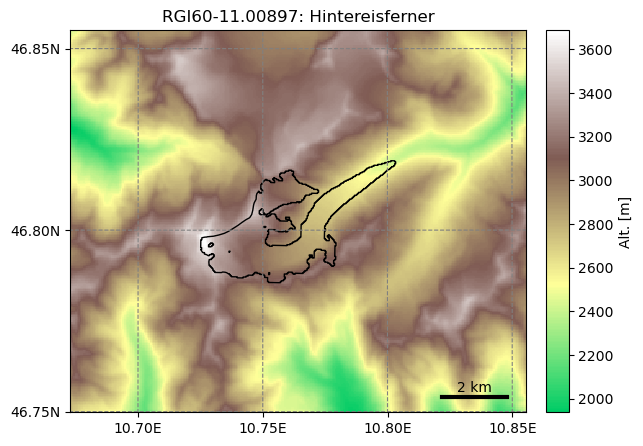

In [15]:
from oggm import graphics
graphics.plot_domain(gdirs[0])

This data uses a `COPDEM90` file but you can use other DEM's make sure you check the following tutorials to know more about how you can change the DEM or use a customise DEM. 

Related Tutorials:

[dem_sources](https://tutorials.oggm.org/stable/notebooks/tutorials/dem_sources.html): Create local topography maps from different DEM sources with OGGM

[rgitopo_rgi6](https://tutorials.oggm.org/stable/notebooks/tutorials/rgitopo_rgi6.html): RGI-TOPO for RGI v6.0

In [16]:
print('My data is here', gdirs[0].dir)
os.listdir(gdirs[0].dir)

My data is here /tmp/OGGM/OGGM-full_prepro_elevation_bands/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897


['glacier_grid.json',
 'intersects.tar.gz',
 'log.txt',
 'outlines.tar.gz',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt']

## Level 2 — Define glacier flowlines and bedshape geometry

At this stage, OGGM defines how the glacier geometry will be represented in the model.

In this tutorial, we only use the `elevation_band` workflow to keep the setup simple. A later tutorial will compare this approach with geometrical centerlines and explain their differences between the two types of flowlines in more detail.

Elevation-band flowlines are one of the standard ways of running OGGM and are widely used in regional and global glacier modelling.

The tasks below:

- Create the glacier flowline structure, including surface elevation and glacier width.
- Create the downstream flowline extending beyond the glacier terminus for past simulations.
- Optionally ingest additional datasets and project them onto the flowlines.

Data used:

- Glacier outline
- DEM
- Optional additional datasets

In [17]:
elevation_band_task_list = [
        tasks.simple_glacier_masks,
        tasks.elevation_band_flowline,
        tasks.fixed_dx_elevation_band_flowline,
        tasks.compute_downstream_line,
        tasks.compute_downstream_bedshape,
    ]

for task in elevation_band_task_list:
    workflow.execute_entity_task(task, gdirs)

2026-06-05 14:29:48: oggm.workflow: Execute entity tasks [simple_glacier_masks] on 1 glaciers
2026-06-05 14:29:48: oggm.workflow: Execute entity tasks [elevation_band_flowline] on 1 glaciers
2026-06-05 14:29:49: oggm.workflow: Execute entity tasks [fixed_dx_elevation_band_flowline] on 1 glaciers
2026-06-05 14:29:49: oggm.workflow: Execute entity tasks [compute_downstream_line] on 1 glaciers
2026-06-05 14:29:49: oggm.workflow: Execute entity tasks [compute_downstream_bedshape] on 1 glaciers


In [18]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'glacier_grid.json',
 'intersects.tar.gz',
 'inversion_flowlines.pkl',
 'log.txt',
 'outlines.tar.gz',
 'gridded_data.nc',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

**Elevation bands flowlines** can't be display until we start a simulation and have obtained an output. 

- Instead of asking OGGM to create this information from scratch level 0-2, the option below allows you to download an already prepared glacier directory from the OGGM server with these type of flowlines.

> **IMPORTANT**: make sure the URL you use correspond to the specific set up you need for your project. If you want elevation bands the URL should reflect that.

In this example:

```python
from_prepro_level=2
```

Will dowload the information that we computed above from the OGGM server instead of actually computing it. 

In [19]:
print(load_from_prepro_base_url)
print('Change this to True if you want to test this tasks')

False
Change this to True if you want to test this tasks


In [20]:
# Instruction for beginning with existing OGGM's preprocessed directories
if load_from_prepro_base_url:
    prepro_base_url_L2 = DEFAULT_BASE_URL
    
    gdirs = workflow.init_glacier_directories(rgi_ids,
                                              from_prepro_level=2,
                                              prepro_base_url=prepro_base_url_L2,
                                              prepro_border=80,  # could be 10, 80, 160 or 240
                                              reset=True,
                                              force=True,
                                             )

## Level 3 — “Connecting glacier geometry with climate and physics”

You already have: 
- glacier geometry
- DEM
- Flowlines

Now OGGM must: 
1. Add climate
2. Estimate the glacier surface mass balance distribution accross elevation bands.
3. Having a distribution of mass flux inferred ice thickness using the physics of ice flow (Shallow Ice Approximation)
4. Prepare the present day state of the glacier for a dynamical run (before running the evolution under a climate scenario).

I will stick with the following decisions: 

                LEVEL 3
   Climate + Calibration + Inversion

                       │
                       ▼
        Are you using standard OGGM inputs?
                       
         ┌─────────────────────────┐
         │ Default outlines        │
         │ Default DEM             │
         │ GSWP3_W5E5 climate      │
         │ No custom MB obs        │
         └─────────────────────────┘
                       
             ┌──────────────┐
             │ YES          │
             └──────────────┘
                       │
                       ▼
        Use standard OGGM calibration
                       
                       │
                       ▼
            A. process_climate_data
                       │
            B. mb_calibration_from_
                 geodetic_mb
                       │
            C. apparent_mb_from_
                   any_mb
                       │
            D. calibrate_inversion_
                from_consensus
                       │
            E. init_present_time_
                   glacier

### **Part A: Get the climate**

In [21]:
# define the climate data to use, we keep the default
print(cfg.PARAMS['baseline_climate'])
cfg.PARAMS['baseline_climate'] = cfg.PARAMS['baseline_climate']

# add climate data to gdir
workflow.execute_entity_task(tasks.process_climate_data, gdirs)

2026-06-05 14:29:49: oggm.workflow: Execute entity tasks [process_climate_data] on 1 glaciers


GSWP3_W5E5


[None]

In [22]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'climate_historical.nc',
 'glacier_grid.json',
 'intersects.tar.gz',
 'inversion_flowlines.pkl',
 'log.txt',
 'outlines.tar.gz',
 'gridded_data.nc',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

In [23]:
import xarray as xr

climate_file = xr.open_dataset(gdirs[0].get_filepath('climate_historical'))
climate_file

<xarray.Dataset> Size: 29kB
Dimensions:   (time: 1428)
Coordinates:
  * time      (time) datetime64[ns] 11kB 1901-01-01 1901-02-01 ... 2019-12-01
Data variables:
    prcp      (time) float32 6kB ...
    temp      (time) float32 6kB ...
    temp_std  (time) float32 6kB ...
Attributes:
    ref_hgt:         2252.0
    ref_pix_lon:     10.75
    ref_pix_lat:     46.75
    ref_pix_dis:     5629.566753389074
    climate_source:  GSWP3_W5E5
    yr_0:            1901
    yr_1:            2019
    author:          OGGM
    author_info:     Open Global Glacier Model

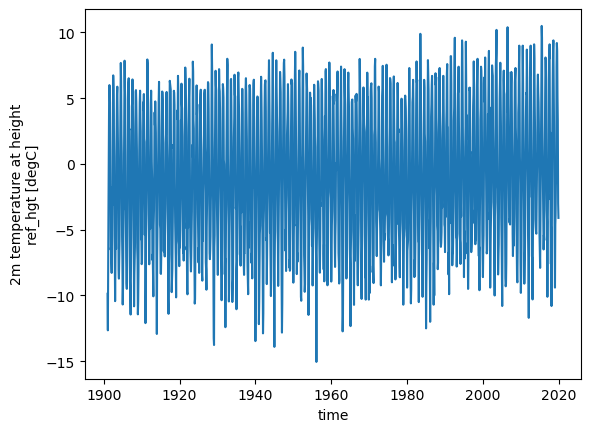

In [24]:
climate_file.temp.plot()

### **Part B:  default MB calibration**

This part is explain in this other more advance tutorial: [Mass balance calibration](https://tutorials.oggm.org/stable/notebooks/tutorials/massbalance_calibration.html) and is hard to fully explain in this tutorial. But we will try to give you an idea. 

The monthly mass balance ($B_i$) at elevation (z) is computed as: 


$B_i(z) = P_i^{\mathrm{Solid}}(z) - d_f , \max \left( T_i(z) - T_{\mathrm{Melt}}, 0 \right)$

where:

- $P_i^{\mathrm{Solid}}(z)$ is the monthly solid precipitation at elevation (z)
- $T_i(z)$ is the monthly air temperature at elevation (z). (plotted above)
- $T_{\mathrm{Melt}}$ is the temperature above which melt is assumed to occur, with a default value of $(-1^\circ\mathrm{C})$
- **$d_f$ is the melt factor**, called `melt_f` in the OGGM code

Some default values below:

In [25]:
cfg.PARAMS['temp_melt']

-1.0

### Solid precipitation is computed from total precipitation. 

The fraction of precipitation that falls as snow depends on the monthly mean temperature: it is all solid below `temp_all_solid`, which defaults to (0 $^\circ{C}$), all liquid above `temp_all_liq`, which defaults to (2$^\circ{C}$), and changes linearly between these two thresholds.

Total precipitation comes from the climate dataset and is multiplied by a precipitation correction factor, `prcp_fac`.

In [26]:
cfg.PARAMS['temp_all_solid']

0.0

In [27]:
cfg.PARAMS['temp_all_liq']

2.0

The model also needs **temperature and precipitation at the glacier elevation (z).**

By default, OGGM uses a fixed temperature lapse rate of (-6.5$\ {K\ km^{-1}}$) and **no precipitation gradient**.

The goal of the default mass-balance calibration is to adjust these model parameters (`melt_f`, `temp_bias`, `prcp_fac`) so that the simulated glacier-wide mass balance matches geodetic observations from January 2000 to January 2020 from [Hugonnet et al. 2021](https://www.nature.com/articles/s41586-021-03436-z). These observations are available for almost every glacier worldwide.

We will jump to a more advanced tutorial for MB calibration in the afternoon session. For now lets concentrate on learning where the calibration information is stored:

In [28]:
print(gdirs[0].get_filepath('mb_calib'))

/tmp/OGGM/OGGM-full_prepro_elevation_bands/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/mb_calib.json


In [29]:
df = gdirs[0].read_json('mb_calib', allow_empty=True)

In [30]:
df

{}

In [31]:
# the default mb calibration
workflow.execute_entity_task(tasks.mb_calibration_from_geodetic_mb,
                             gdirs,
                             informed_threestep=True,  # only available for 'GSWP3_W5E5'
                            )
# Important: if you are not using the dev change this to: tasks.mb_calibration_from_hugonnet_mb and you will need to read the settings.yml file
# instead

2026-06-05 14:29:49: oggm.workflow: Execute entity tasks [mb_calibration_from_geodetic_mb] on 1 glaciers


[{'rgi_id': 'RGI60-11.00897',
  'bias': 0,
  'melt_f': 5.0,
  'prcp_fac': 3.589780370819135,
  'temp_bias': np.float64(1.705035916562294),
  'reference_mb': np.float64(-1100.3),
  'reference_mb_err': np.float64(171.8),
  'reference_period': '2000-01-01_2020-01-01',
  'mb_global_params': {'temp_default_gradient': -0.0065,
   'temp_all_solid': 0.0,
   'temp_all_liq': 2.0,
   'temp_melt': -1.0},
  'baseline_climate_source': 'GSWP3_W5E5'}]

In [32]:
df = gdirs[0].read_json('mb_calib')
df

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 3.589780370819135,
 'temp_bias': 1.705035916562294,
 'reference_mb': -1100.3,
 'reference_mb_err': 171.8,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

With `informed_threestep=True` in here:  

```python
workflow.execute_entity_task(tasks.mb_calibration_from_geodetic_mb,
                             gdirs,
                             informed_threestep=True,  # only available for 'GSWP3_W5E5'
                            )
```


OGGM uses a more guided 3-step calibration instead of only calibrating `melt_f`.

It does this:

- Gets an initial `temp_bias` from a precomputed temperature-bias table, based on the glacier’s climate grid point.
- Computes an initial `prcp_fac` using [`decide_winter_precip_factor(gdir)`](https://github.com/OGGM/oggm/blob/ce43d7cd49ef76f27553302c5222cfe509da68af/oggm/core/massbalance.py#L1452-L1502).
- Allows `prcp_fac` to vary only within ±20% of that initial value.
- Calls [`mb_calibration_from_scalar_mb`](https://github.com/OGGM/oggm/blob/ce43d7cd49ef76f27553302c5222cfe509da68af/oggm/core/massbalance.py#L1974) with this calibration order.

> **Note**: that the task [`mb_calibration_from_scalar_mb`](https://github.com/OGGM/oggm/blob/ce43d7cd49ef76f27553302c5222cfe509da68af/oggm/core/massbalance.py#L1974) is the actual task that preforms the calibration and can be used to calibrate to any SMB observation!


```python
calibrate_param1='prcp_fac'
calibrate_param2='melt_f'
calibrate_param3='temp_bias'
```

In the informed three-step calibration, OGGM first estimates an initial precipitation correction factor (prcp_fac) from winter precipitation. It then allows this value to vary within a limited range, ±20%, and first tries to match the Hugonnet geodetic mass balance by adjusting `prcp_fac`. If this is not enough, OGGM next adjusts the melt factor (`melt_f`). If the observations still cannot be matched, it finally adjusts the temperature bias (`temp_bias`).

This option only works for suitable baseline climate datasets, such as W5E5 or ERA5. It also requires `cfg.PARAMS['prcp_fac']` to be unset, because the method needs to compute its own initial `prcp_fac` before calibrating it.

### **The order of calibration can also be changed** depending on the user’s needs and on which parameters are already known.

For example, if a precipitation correction factor (`prcp_fac`) has already been estimated (e.g. by OGGM developers for an specific climate reanalysis), we may not want OGGM to recalibrate it. In that case, `prcp_fac` can be passed directly to the calibration task, and the calibration can focus only on the remaining uncertain parameter(s), such as the melt factor (`melt_f`) or temperature bias (`temp_bias`).

```python
for gdir in gdirs:
            mb_calib = gdir.read_json('mb_calib')

            tasks.mb_calibration_from_scalar_mb(
                gdir,
                ref_mb=mb_calib['reference_mb'],
                ref_mb_err=mb_calib['reference_mb_err'],
                ref_mb_period=mb_calib['reference_period'],
                settings_filesuffix='',
                observations_filesuffix='',
                write_to_gdir=True,
                overwrite_gdir=True,
                overwrite_observations=True,
                calibrate_param1='melt_f',
                calibrate_param2=None,
                calibrate_param3=None,
                prcp_fac=mb_calib['prcp_fac'],
                temp_bias=mb_calib['temp_bias'],
                mb_model_class=MBModel,
                filename=climate_filename
            )
```

We will learn how to use the other ways of calibration in the advance tutorials.

### **Part C:  with parms calibrated compute MB for a historical climate**

In [33]:
workflow.execute_entity_task(tasks.apparent_mb_from_any_mb, gdirs)

2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [apparent_mb_from_any_mb] on 1 glaciers


[None]

**Lets visualise this** against WGMS sdata and geodetic observations from January 2000 to January 2020 from [Hugonnet et al. 2021](https://www.nature.com/articles/s41586-021-03436-z)

> Note: the code below is just so you can visualise how to plot the OGGM mass balance model time series vs WGMS and geodetic data. This should also teach you how to where things are stored in OGGM and how to download MB observations into your glacier directory or simulation. 

In [34]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'climate_historical.nc',
 'glacier_grid.json',
 'intersects.tar.gz',
 'inversion_flowlines.pkl',
 'log.txt',
 'outlines.tar.gz',
 'gridded_data.nc',
 'mb_calib.json',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

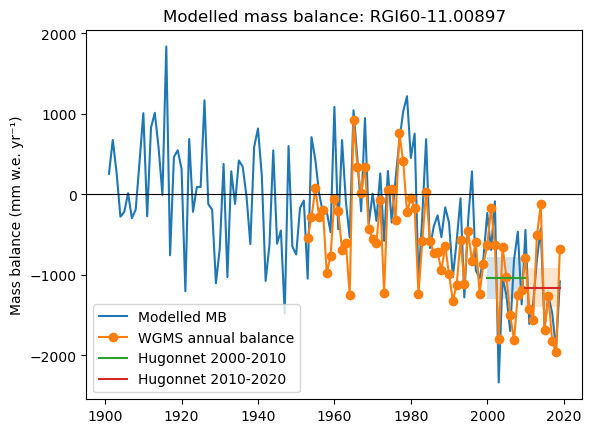

In [35]:
from oggm.core import massbalance
import pandas as pd
import matplotlib.pyplot as plt

hug_df = utils.get_geodetic_mb_dataframe()


for gdir in gdirs:
    # Flowline geometry used for the specific MB calculation
    fls = gdir.read_pickle('inversion_flowlines')
    h, w = gdir.get_inversion_flowline_hw()

    # Calibrated mass-balance model
    mb_mod = massbalance.MonthlyTIModel(gdir)

    # Years to plot: use the available climate period
    years = range(mb_mod.ys, mb_mod.ye + 1)

    # Modelled glacier-wide specific MB
    mb_ts = pd.DataFrame(index=years)
    mb_ts['modelled_mb'] = mb_mod.get_specific_mb(
        heights=h,
        widths=w,
        year=mb_ts.index
    )

    # Optional: add WGMS observations if available
    try:
        wgms_mb = gdir.get_ref_mb_data()
        mb_ts['WGMS_ANNUAL_BALANCE'] = wgms_mb['ANNUAL_BALANCE']
    except Exception:
        wgms_mb = None

    # Select Hugonnet data for this glacier
    hug_gdir = hug_df.loc[gdir.rgi_id]

    # Add Hugonnet reference periods as step values
    for period in [
        '2000-01-01_2010-01-01',
        '2010-01-01_2020-01-01',
    ]:
        sel = hug_gdir.loc[hug_gdir.period == period].iloc[0]

        y0 = int(period.split('_')[0].split('-')[0])
        y1 = int(period.split('_')[1].split('-')[0])

        # Hugonnet is in m w.e. yr-1; convert to mm w.e. yr-1
        ref_mb = sel['dmdtda'] * 1000
        ref_err = sel['err_dmdtda'] * 1000

        mb_ts.loc[y0:y1-1, f'Hugonnet {y0}-{y1}'] = ref_mb
        mb_ts.loc[y0:y1-1, f'Hugonnet {y0}-{y1} err'] = ref_err

    # Plot modelled MB and WGMS observations
    ax = mb_ts['modelled_mb'].plot(
        label='Modelled MB',
        title=f'Modelled mass balance: {gdir.rgi_id}'
    )

    if wgms_mb is not None:
        mb_ts['WGMS_ANNUAL_BALANCE'].plot(
            ax=ax,
            marker='o',
            linestyle='-',
            label='WGMS annual balance'
        )

    for period in [
        '2000-01-01_2010-01-01',
        '2010-01-01_2020-01-01',
    ]:
        y0 = int(period.split('_')[0].split('-')[0])
        y1 = int(period.split('_')[1].split('-')[0])

        ref_col = f'Hugonnet {y0}-{y1}'
        err_col = f'Hugonnet {y0}-{y1} err'

        if ref_col in mb_ts:
            ax.step(
                mb_ts.index,
                mb_ts[ref_col],
                where='post',
                label=f'Hugonnet {y0}-{y1}'
            )

            ax.fill_between(
                mb_ts.index,
                mb_ts[ref_col] - mb_ts[err_col],
                mb_ts[ref_col] + mb_ts[err_col],
                alpha=0.2
            )

    ax.axhline(0, color='k', linewidth=0.8)

    ax.set_ylabel('Mass balance (mm w.e. yr⁻¹)')
    ax.legend()
    plt.show()

### **Part D:  Calibrate the ice thickness computation to a reference volume estimate**

#### **Ice flux and mass conservation**

Step C, provided a glacier-wide mass balance distribution. To estimate glacier thickness, OGGM first needs to compute the ice flux flowing through each cross-section of the glacier.  

In the physics of ice, the ice flux should be computed from the continuity equation:

$q = \int_{\Omega}
\left(
\dot{m} - \rho \frac{\partial h}{\partial t}
\right)
, dA$

where:

- $q$ is the ice flux,
- $\dot{m}$ is the climatic mass balance,
- $\rho \frac{\partial h}{\partial t}$ represents changes in glacier thickness through time,
- $\Omega$ is the upstream glacier area contributing ice to that cross-section.

If the glacier is in steady state, then

$\frac{\partial h}{\partial t}=0$

and the actual (observable) mass balance is equivalent to the apparent mass balance used by the inversion. Unfortunately, **most glaciers are not in equilibrium**, and $\partial h / \partial t$ is generally unknown. There is therefore no straightforward way to compute the flux directly from MB observations.

To continue, OGGM makes the assumption that the **observed glacier geometry is in equilibrium with the reference surface mass-balance distribution. In other words, OGGM computes the mass-balance distribution that would be required to maintain the present-day glacier geometry in steady state. This is called the apparent mass balance in [Farinotti et. al 2009](https://www.cambridge.org/core/journals/journal-of-glaciology/article/method-to-estimate-the-ice-volume-and-icethickness-distribution-of-alpine-glaciers/40D2B92744F6512E8DEC142DE6BEA471):

$\dot{m} \rho \frac{\partial h}{\partial t}$

$q = \int_{\Omega} \widetilde{m}, dA$

This equilibrium assumption is one of the main limitations of glacier thickness inversions which are based on mass conservation such as those that are derived or are similar to [Farinotti et. al 2009](https://www.cambridge.org/core/journals/journal-of-glaciology/article/method-to-estimate-the-ice-volume-and-icethickness-distribution-of-alpine-glaciers/40D2B92744F6512E8DEC142DE6BEA471).

#### **From ice flux to ice thickness**

Once the ice flux is known, OGGM uses the [**Shallow Ice Approximation (SIA)**](https://www.antarcticglaciers.org/glaciers-and-climate/numerical-ice-sheet-models/hierarchy-ice-sheet-models-introduction/) to estimate ice thickness. Under the SIA, the ice flux is related to glacier geometry and ice-flow physics by:

$q = u S = \left( f_d h \tau^n + f_s \frac{\tau^n}{h} \right) S$

where:

- (u) is the depth-averaged ice velocity,
- (S) is the cross-sectional area,
- (h) is ice thickness,
- ($\tau$) is the driving stress,
- (n) is Glen's flow-law exponent,
- ($f_d$) controls ice deformation,
- ($f_s$) controls basal sliding.

more in [Maussion et al. 2019](https://gmd.copernicus.org/articles/12/909/2019/)


In [36]:
# Min ice-dynamics and inversion parameters used by OGGM
import pandas as pd

inversion_params = {
    'ice_density': 'Ice density [kg m-3]',
    'glen_n': "Glen's flow-law exponent",
    'inversion_glen_a': "Glen A used for thickness inversion",
    'glen_a': "Glen A used for forward runs",
    'inversion_fs': "Sliding parameter used for thickness inversion",
    'fs': "Sliding parameter used for forward runs",
    'min_slope': "Minimum slope for inversion [degrees]",
    'min_slope_ice_caps': "Minimum slope for ice-cap inversion [degrees]",
    'min_slope_flowline_filter': "Minimum slope during flowline filtering",
    'distributed_inversion_min_slope': "Minimum slope for distributed inversion",
}

df = pd.DataFrame(
    [
        {
            'parameter': key,
            'value': f"{cfg.PARAMS[key]:g}",
            'description': description,
        }
        for key, description in inversion_params.items()
    ]
)

df

,parameter,value,description
0,ice_density,900,Ice density [kg m-3]
1,glen_n,3,Glen's flow-law exponent
2,inversion_glen_a,2.4e-24,Glen A used for thickness inversion
3,glen_a,2.4e-24,Glen A used for forward runs
4,inversion_fs,0,Sliding parameter used for thickness inversion
5,fs,0,Sliding parameter used for forward runs
6,min_slope,1.5,Minimum slope for inversion [degrees]
7,min_slope_ice_caps,1.5,Minimum slope for ice-cap inversion [degrees]
8,min_slope_flowline_filter,0,Minimum slope during flowline filtering
9,distributed_inversion_min_slope,6,Minimum slope for distributed inversion


#### Calibration of the inversion parameters

The deformation parameter $f_{d}$ depends on Glen's flow-law parameter (A or `inversion_glen_a` in the code):

$f_d = \frac{2A}{n+2}$

Therefore, changing ($A$) changes the ice thickness required to transport a given ice flux. To account for uncertainties in glacier rheology and inversion assumptions, OGGM calibrates ($A$) against an independent estimate of glacier volume:


$A = f_{\mathrm{inv}} A_0$

where:

- $(A_0)$ is the default Glen parameter,
- $(f_{\mathrm{inv}})$ is a calibration factor.

The following code is incharge of that: 

In [37]:
out = workflow.calibrate_inversion_from_consensus(
    gdirs,
    apply_fs_on_mismatch=True,
    error_on_mismatch=True,  # if you are running many glaciers some might not work
    filter_inversion_output=True,  # this partly filters the overdeepening due to
    # the equilibrium assumption for retreating glaciers (see. Figure 5 of Maussion et al. 2019)
    volume_m3_reference=None,  # here you could provide your own total volume estimate in m3
)

2026-06-05 14:29:50: oggm.workflow: Applying global task calibrate_inversion_from_consensus on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Consensus estimate optimisation with A factor: 0.1 and fs: 0
2026-06-05 14:29:50: oggm.workflow: Applying global task inversion_tasks on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [prepare_for_inversion] on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [mass_conservation_inversion] on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [filter_inversion_output] on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [get_inversion_volume] on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Consensus estimate optimisation with A factor: 10.0 and fs: 0
2026-06-05 14:29:50: oggm.workflow: Applying global task inversion_tasks on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [prepare_for_inversion] on 1 glaciers
2026-06-05 14:29:50: oggm.workflow: Execute

In [38]:
out

,vol_itmix_m3,vol_bsl_itmix_m3,vol_oggm_m3
RGIId,,,
RGI60-11.00897,5.778528e+08,0.0,5.778570e+08


In [39]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'inversion_input.pkl',
 'climate_historical.nc',
 'glacier_grid.json',
 'intersects.tar.gz',
 'inversion_flowlines.pkl',
 'log.txt',
 'outlines.tar.gz',
 'gridded_data.nc',
 'mb_calib.json',
 'dem.tif',
 'inversion_output.pkl',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

This information is stored in `diagnostics.json`. and can be retrieved by:

In [40]:
rows = []

for gdir in gdirs:
    rows.append({
        'rgi_id': gdir.rgi_id,
        'inversion_glen_a': gdir.get_diagnostics()['inversion_glen_a'],
        'inversion_fs': gdir.get_diagnostics()['inversion_fs'],
        'vol_oggm_m3': out.loc[gdir.rgi_id, 'vol_oggm_m3'],
    })

pd.DataFrame(rows)

df = pd.DataFrame(rows)
df['glen_a_factor'] = df['inversion_glen_a'] / cfg.PARAMS['inversion_glen_a']
df

,rgi_id,inversion_glen_a,inversion_fs,vol_oggm_m3,glen_a_factor
0,RGI60-11.00897,6.396018e-24,0,5.778570e+08,2.665008


#### Note on Ice dynamic calibration

The task searches for the value of $f_{\mathrm{inv}}$ that makes the **total modelled glacier volume** match the **total reference volume** from the consensus estimate in [Farinotti_et_al_2019](https://www.nature.com/articles/s41561-019-0300-3).

Importantly, the calibration is **not performed glacier by glacier like the mass balance**. Although the consensus dataset provides an individual volume estimate for each glacier, OGGM does not try to match each glacier separately. Instead, it compares the sum of all modelled volumes with the sum of all reference volumes and finds a single value of $f_{\mathrm{inv}}$ that minimizes the mismatch across the entire glacier sample (though in our case here is only one glacier).

$
\sum_i V_{\mathrm{OGGM},i} = \sum_i V_{\mathrm{ref},i}
$

rather than

$ V_{\mathrm{OGGM},i} = V_{\mathrm{ref},i} \quad \forall i $

Because one common inversion parameter is optimised for all glaciers simultaneously, `calibrate_inversion_from_consensus` is implemented as a **global task** rather than an **entity task**. The resulting value of $f_{\mathrm{inv}}$ represents a regional or sample-wide calibration of glacier rheology, not a glacier-specific calibration.

As a consequence, individual glaciers may still be over- or under-estimated, even when the total volume of the glacier sample matches the consensus estimate very well.

### **Part E: Initialise present day glacier**

After the ice-thickness inversion, OGGM has estimated the ice thickness and volume along the inversion flowlines. However, these inversion flowlines are not yet the final objects used for glacier evolution simulations.

The next task `init_present_time_glacier` converts the inversion output into model flowlines, also called [dynamic flowlines](https://docs.oggm.org/en/stable/ice-dynamics.html#). These are the flowlines that OGGM’s ice-dynamics model will use to evolve the glacier geometry through time.

In [41]:
# finally create the dynamic flowlines
workflow.execute_entity_task(tasks.init_present_time_glacier, gdirs);

2026-06-05 14:29:50: oggm.workflow: Execute entity tasks [init_present_time_glacier] on 1 glaciers


#### Continuity equation and glacier evolution

In other words, this task combines the geometrical flowline structure with the ice thickness computed by the inversion. The result is a present-day glacier geometry that is ready to be passed to the ice-dynamical evolution model.

Conceptually, this step transforms:

`inversion_flowlines` + `inversion_output`

`↓`

`model_flowlines`

For each flowline element, the continuity equation (volume and mass conservation) implies:

$ \frac{\partial S}{\partial t} = w \dot{m} - \nabla \cdot q $

where $(S)$ is the cross-sectional area, $w$ is the glacier width, $\dot{m}$ is the climatic mass balance, and $q = uS$ is the ice flux.

This equation says that the cross-section of a glacier changes through time, because of two processes: 
- local gain or loss of ice from surface mass balance, $w\dot{m}$,
- and the convergence or divergence of ice flux along the flowline, $\nabla \cdot q$.

In [42]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'inversion_input.pkl',
 'climate_historical.nc',
 'glacier_grid.json',
 'model_flowlines.pkl',
 'intersects.tar.gz',
 'inversion_flowlines.pkl',
 'log.txt',
 'outlines.tar.gz',
 'gridded_data.nc',
 'mb_calib.json',
 'dem.tif',
 'inversion_output.pkl',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

This taks creates the `model_flowlines.pkl` where the information of the thickness evolution will be stored.

These model_flowlines are the fundamental objects used by OGGM's glacier evolution models. They contain the present-day glacier geometry, including:

- the bed elevation,
- the initial ice thickness,
- the surface elevation,
- the cross-sectional area,
- the glacier width,
- the bed shape,
- and the flowline connections between tributaries and the main glacier.

You can inspect them with:

In [43]:
gdir = gdirs[0]

fls = gdir.read_pickle('model_flowlines')

In [44]:
fls[-1].thick

array([ 32.20505947,  36.30947524,  36.24710073,  40.63277337,
        43.36209817,  50.23257628,  54.20658963,  51.15171274,
        49.45755033,  50.84239151,  54.35689401,  57.39378469,
        61.94062647,  65.2596488 ,  65.55426706,  64.25935104,
        69.46888179,  83.36785154,  98.54053194, 112.85747699,
       124.14364097, 132.29395583, 138.66932047, 144.94677516,
       153.07838563, 156.63928315, 146.6156469 , 130.41407228,
       113.29484448, 106.07368015, 115.69051867, 126.98200996,
       134.39748976, 137.80847396, 132.17248396, 127.83626909,
       124.3974612 , 119.39077326, 113.15734821, 106.26649066,
       103.17075807, 102.32071151, 100.76667862,  98.43512286,
        94.08263965,  85.38204366,  62.90613805,  42.90910877,
        31.79890651,  21.41068007,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

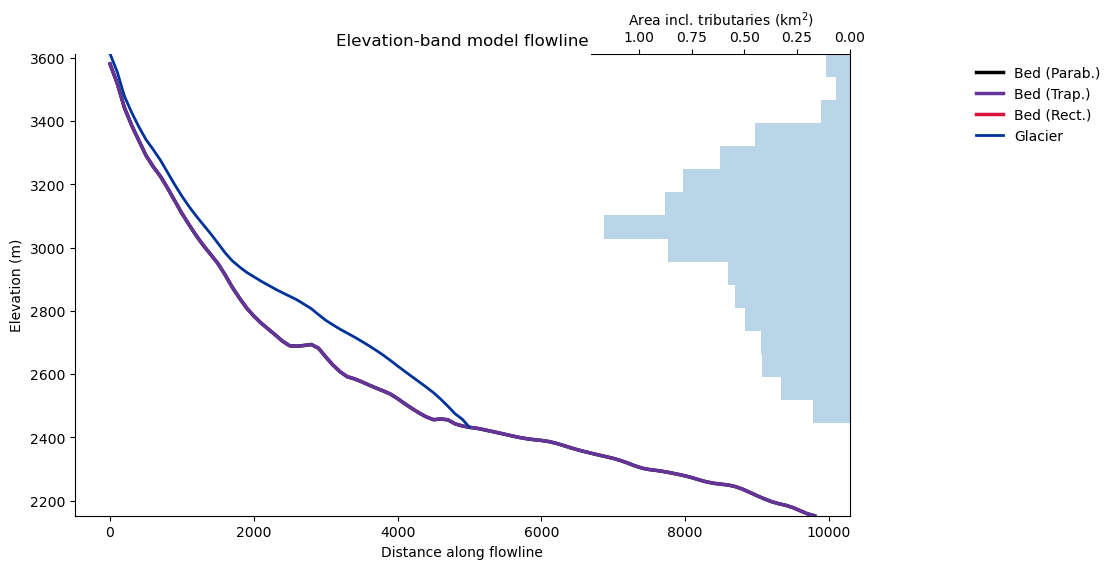

In [45]:
from oggm import graphics
import matplotlib.pyplot as plt

fls = gdir.read_pickle('model_flowlines')

f, ax = plt.subplots(figsize=(10, 6))

graphics.plot_modeloutput_section(fls, ax=ax)

ax.set_title('Elevation-band model flowline')
ax.set_xlabel('Distance along flowline')
ax.set_ylabel('Elevation (m)')
plt.show()

This plot shows the geometry that will be used as the initial condition for the dynamic model: the glacier surface, bed, ice thickness, and elevation distribution along the model flowline.

In short: `model_flowlines` **are the initial present-day glacier geometry that OGGM evolves forward in time.**

#### How to use preprocessing Level 3

If you are happy with the standard OGGM setup, you do not need to rerun all Level 0–3 tasks yourself.

Instead, you can download an already prepared Level 3 glacier directory:

```python
gdirs = workflow.init_glacier_directories(
    rgi_ids,
    from_prepro_level=3,
    prepro_base_url=prepro_base_url_L3,
    prepro_border=80,  # could be 80 or 160
    reset=True,
    force=True,
)
```

So no need to re-do all computations shown in this tutorial just do: 

In [46]:
load_from_prepro_base_url

False

In [47]:
# Instruction for beginning with existing OGGM's preprocessed directories
if load_from_prepro_base_url:
    prepro_base_url_L3 = DEFAULT_BASE_URL
    gdirs = workflow.init_glacier_directories(rgi_ids,
                                              from_prepro_level=3,
                                              prepro_base_url=prepro_base_url_L3,
                                              prepro_border=80,  # could be 10, 80, 160 or 240
                                              reset=True,
                                              force=True,
                                             )